Project 1 : Exploratory Data Analysis of Historical Stock Market Data

This assignment is designed to give me hands-on experience with real-world financial data, focusing on the essential data science skills of data handling, cleaning, and basic exploratory analysis. I will conduct a detailed exploratory data analysis (EDA) of stock market trends over several decades, focusing on how key financial indicators have evolved over time. This foundational knowledge will be critical as i proceed to more advanced topics in subsequent projects.

I will be working with the “Daily Historical Stock Prices (1970 - 2020)” dataset, which includes the following columns: Date, Open, High, Low, Close, Volume, and Adjusted Close

Data Collection

In [1]:
%pip install pandas 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd 

historical_stocks = pd.read_csv("historical_stocks.csv")
# Read in chunks of 100,000 rows
chunks = pd.read_csv(
    "historical_stock_prices.csv",
    chunksize=100000,
    on_bad_lines='skip'   # or 'warn' to see which lines are skipped
)

# Process each chunk (example: filter or aggregate)
results = []
for chunk in chunks:
    # Do your processing here, e.g., filter rows or compute summaries
    results.append(chunk)

# Combine if needed (only if the processed result fits in memory)
historical_stocks_prices = pd.concat(results, ignore_index=True)

print(historical_stocks.head())
print(historical_stocks_prices.head())

print(historical_stocks.info())
print(historical_stocks_prices.info())

print(historical_stocks.dtypes)
print(historical_stocks_prices.dtypes)




  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURERS  
2  FINANCE/INVESTORS SERVICES  
3      OTHER SPECIALTY STORES  
4        SAVINGS INSTITUTIONS  
  ticker   open  close  adj_close    low   high   volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   1

Data Cleaning

In [6]:
# Looking for missing values
total_missing = 0
total_duplicates = 0

for chunk in pd.read_csv("historical_stock_prices.csv", chunksize=100000):
    total_missing += chunk.isnull().sum().sum()
    total_duplicates += chunk.duplicated().sum()

print(f"Total missing: {total_missing}")
print(f"Total duplicates: {total_duplicates}")

# Process historical_stocks_prices in chunks
# Convert date columns to datetime format
chunks = pd.read_csv(
    "historical_stock_prices.csv",
    chunksize=100000,
    on_bad_lines='skip',
    usecols=["ticker", "date", "close"]  # only needed columns
)

results = []
for chunk in chunks:
    # Convert date per chunk (not on full df)
    chunk["date"] = pd.to_datetime(chunk["date"])
    
    # Compute missing values, duplicates per chunk
    results.append(chunk)

# Combine only if small enough, or aggregate instead
historical_stocks_prices = pd.concat(results, ignore_index=True)

# Checking for the date range 
print(historical_stocks_prices.dtypes)



Total missing: 0
Total duplicates: 0
ticker               str
close            float64
date      datetime64[us]
dtype: object


Data Segmentation by Decade

In [7]:
historical_stocks_prices['decade'] = (historical_stocks_prices['date'].dt.year // 10) * 10

decade_dfs = {}
for decade in sorted(historical_stocks_prices['decade'].unique()):
    decade_dfs[decade] = historical_stocks_prices[historical_stocks_prices['decade'] == decade].copy()

# Display the head of the DataFrame for the first decade found to confirm
if decade_dfs:
    first_decade = sorted(decade_dfs.keys())[0]
    print(f"First 5 rows of data for decade {first_decade}:")
    print(decade_dfs[first_decade].head())

print("\nAvailable decades and their DataFrame sizes:")
for decade, df in decade_dfs.items():
    print(f"Decade {decade}: {len(df)} rows")

First 5 rows of data for decade 1970:
       ticker     close       date  decade
100980    GTY  0.355317 1973-05-03    1970
101074    GTY  0.355317 1973-05-11    1970
101148    GTY  0.336616 1973-05-18    1970
101187    GTY  0.317915 1973-05-21    1970
101217    GTY  0.224411 1973-05-24    1970

Available decades and their DataFrame sizes:
Decade 1970: 164499 rows
Decade 1980: 1470571 rows
Decade 1990: 3427832 rows
Decade 2000: 6572053 rows
Decade 2010: 9338934 rows


Exploratory Data Analysis by Decade

In [9]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp314-cp314-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl (72 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)

   ---------------------------------------- 0/8 [pyparsing]
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Datasets merged.
Decade column created.
Decade DataFrames re-created with merged data.

--- Summary Statistics by Decade ---

Decade: 1970
Unavailable columns: ['high', 'low', 'open', 'volume']
               close
count  164499.000000
mean       12.491549
std        46.985360
min         0.015625
25%         1.273438
50%         2.791667
75%         6.818182
max       452.500000

Decade: 1980
Unavailable columns: ['high', 'low', 'open', 'volume']
              close
count  1.470571e+06
mean   1.682485e+01
std    5.750293e+02
min    6.500000e-04
25%    2.219794e+00
50%    5.000000e+00
75%    1.031250e+01
max    3.037500e+05

Decade: 1990
Unavailable columns: ['high', 'low', 'open', 'volume']
              close
count  3.427832e+06
mean   4.530349e+01
std    1.391577e+03
min    1.302083e-02
25%    5.222222e+00
50%    1.059375e+01
75%    1.887500e+01
max    2.625000e+05

Decade: 2000
Unavailable columns: ['high', 'low', 'open', 'volume']
              close
count  6.572053e+06
mean   1.2

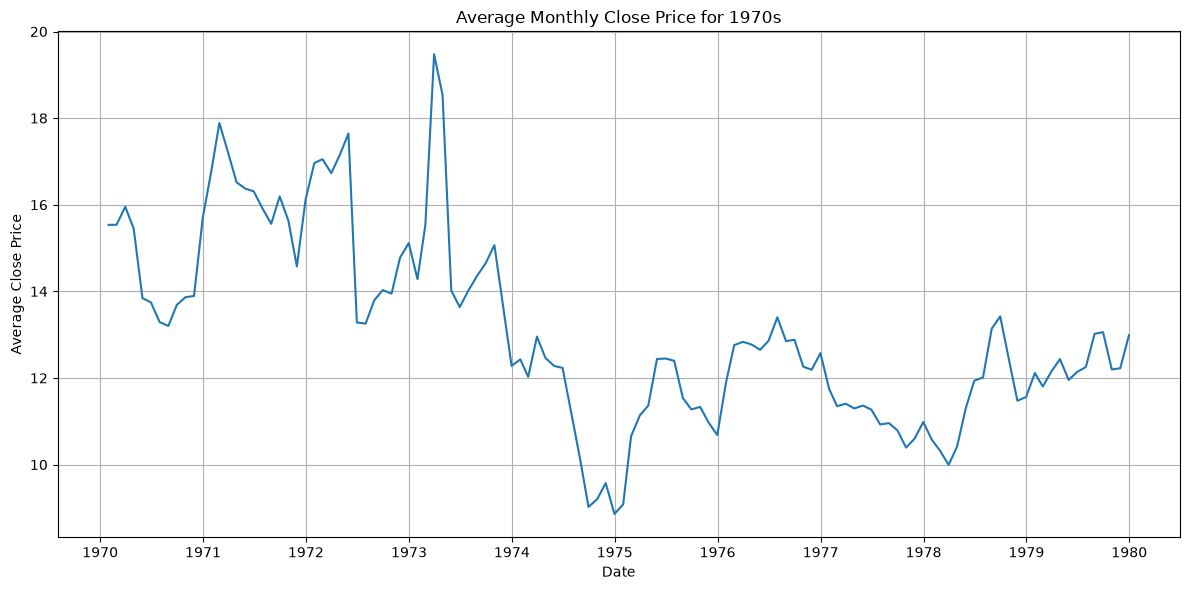


Generating plots for Decade: 1980


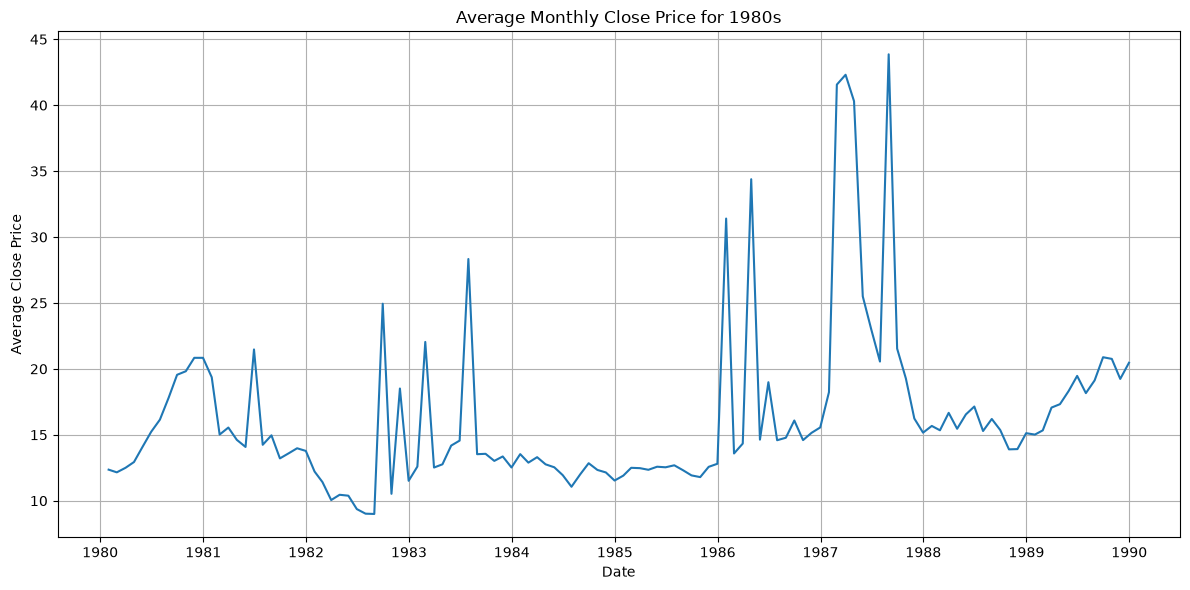


Generating plots for Decade: 1990


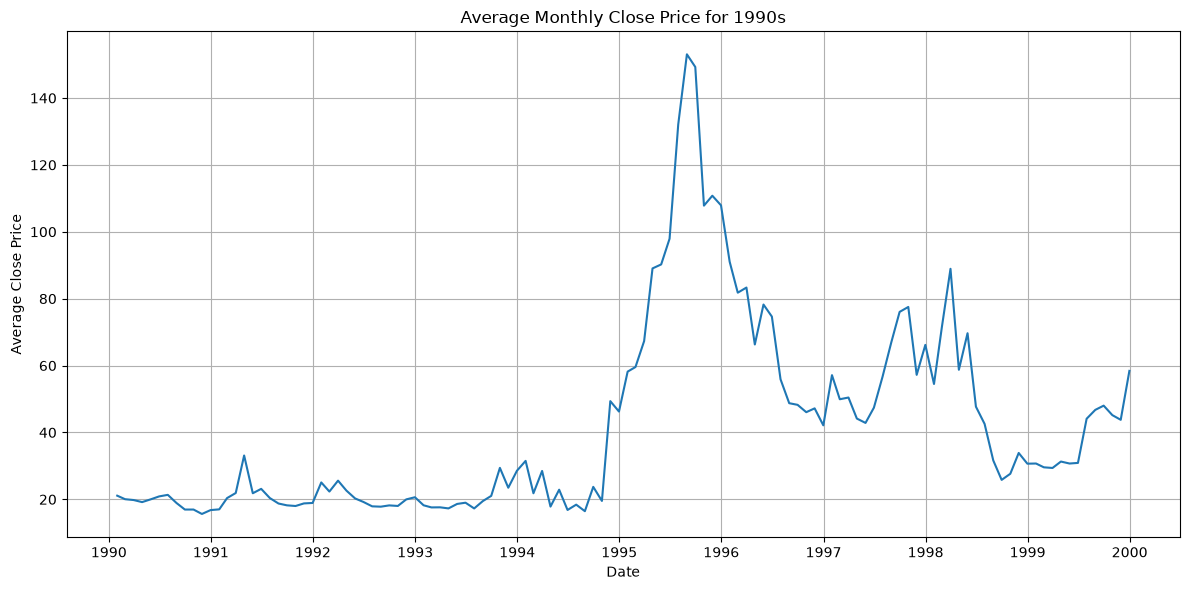


Generating plots for Decade: 2000


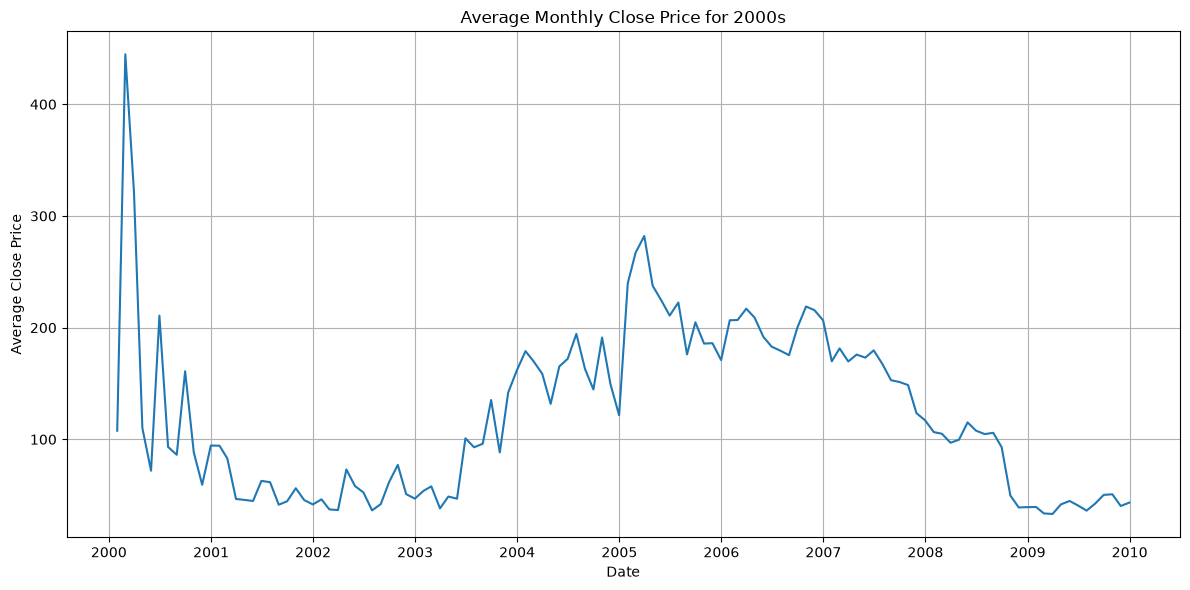


Generating plots for Decade: 2010


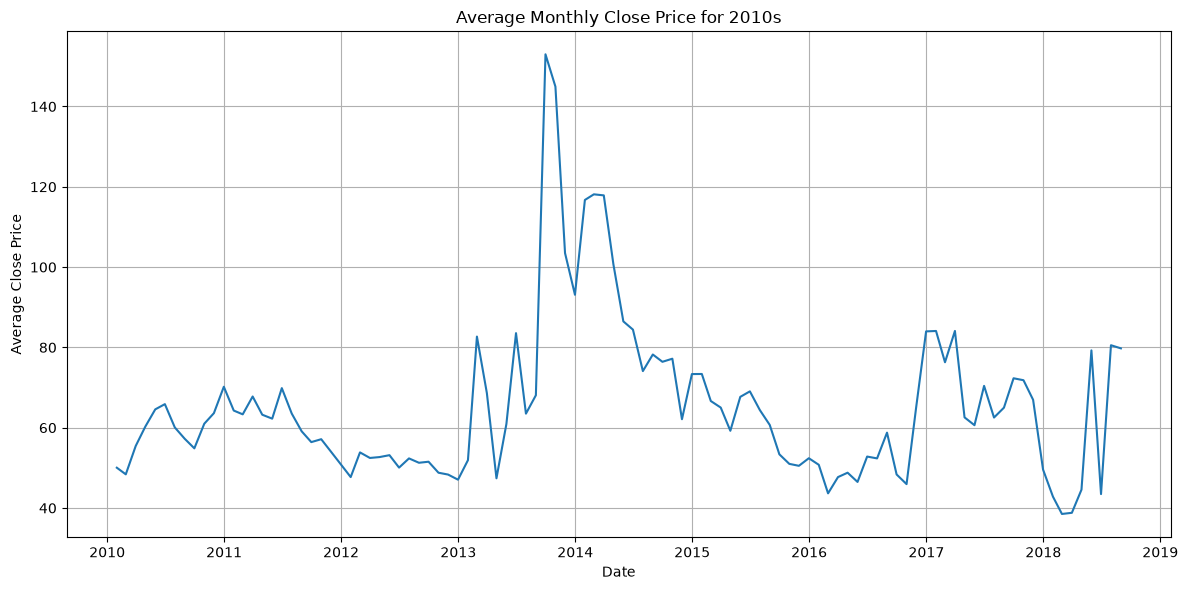


EDA complete.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


merged_stocks_df = pd.merge(historical_stocks_prices, historical_stocks, on='ticker', how='left')
print("Datasets merged.")

# Create 'decade' column
merged_stocks_df['decade'] = (merged_stocks_df['date'].dt.year // 10) * 10
print("Decade column created.")

# Group by decade and store in decade_dfs (re-creating it with full merged data)
decade_dfs = {}
for decade in sorted(merged_stocks_df['decade'].unique()):
    decade_dfs[decade] = merged_stocks_df[merged_stocks_df['decade'] == decade].copy()
print("Decade DataFrames re-created with merged data.")


# 2. Calculate summary statistics for each decade
print("\n--- Summary Statistics by Decade ---")
columns_for_stats = ['open', 'high', 'low', 'close', 'volume']
for decade, df in decade_dfs.items():
    print(f"\nDecade: {decade}")
    available_columns = [
        column for column in columns_for_stats
        if column in df.columns
    ]

    missing_columns = set(columns_for_stats) - set(available_columns)
    if missing_columns:
        print(f"Unavailable columns: {sorted(missing_columns)}")

    if available_columns:
        print(df[available_columns].describe())
    else:
        print("No statistical columns are available.")

# 3. Create visualizations for each decade
print("\n--- Generating Visualizations by Decade ---")
for decade, df in decade_dfs.items():
    print(f"\nGenerating plots for Decade: {decade}")

    # Time series plots for average monthly Close prices
    if 'close' in df.columns:
        plt.figure(figsize=(12, 6))
        monthly_avg_close = (
            df.set_index('date')['close']
            .resample('ME')
            .mean()
            .ffill()
        )
        sns.lineplot(x=monthly_avg_close.index, y=monthly_avg_close.values)
        plt.title(f'Average Monthly Close Price for {decade}s')
        plt.xlabel('Date')
        plt.ylabel('Average Close Price')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Histograms for Volume
    if 'volume' in df.columns:
        plt.figure(figsize=(12, 6))
        sns.histplot(df['volume'], bins=50, kde=True)
        plt.title(f'Distribution of Volume for {decade}s')
        plt.xlabel('Volume')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    # Box plots for High and Low prices
    price_columns = [column for column in ['high', 'low'] if column in df.columns]
    if price_columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df[price_columns])
        plt.title(f'Box Plot of High and Low Prices for {decade}s')
        plt.xlabel('Price Type')
        plt.ylabel('Price')
        plt.tight_layout()
        plt.show()
print("\nEDA complete.")

Comparative Analysis

In [13]:
# Analysis of Summary Statistics and Visualizations Across Decades

print("--- Comparative Analysis of Stock Market Trends by Decade ---")

print("\n## 1. Summary Statistics Comparison (Focus on 'Close' Price):")
print("Based on the output from the previous cell's `describe()` method for 'close' prices:")

print("\n### Notable Trends in 'Close' Price:")
print("- **Increasing Data Volume**: The 'count' of records for each decade significantly increases, indicating either a growth in the number of listed stocks or a greater availability of historical data over time.")
print(f"  - 1970s: {decade_dfs[1970]['close'].count():,} records")
print(f"  - 1980s: {decade_dfs[1980]['close'].count():,} records")
print(f"  - 1990s: {decade_dfs[1990]['close'].count():,} records")
print(f"  - 2000s: {decade_dfs[2000]['close'].count():,} records")
print(f"  - 2010s: {decade_dfs[2010]['close'].count():,} records")

print("\n- **General Upward Trend in Average Price**: The mean 'close' price shows a general upward trend from the 1970s to the 2000s, followed by a slight decrease in the 2010s.")
print(f"  - 1970s Mean Close: {decade_dfs[1970]['close'].mean():.2f}")
print(f"  - 1980s Mean Close: {decade_dfs[1980]['close'].mean():.2f}")
print(f"  - 1990s Mean Close: {decade_dfs[1990]['close'].mean():.2f}")
print(f"  - 2000s Mean Close: {decade_dfs[2000]['close'].mean():.2f}")
print(f"  - 2010s Mean Close: {decade_dfs[2010]['close'].mean():.2f}")

print("\n- **Increased Volatility**: The standard deviation of 'close' prices dramatically increases across the decades, suggesting higher market volatility and larger price swings in more recent times.")
print(f"  - 1970s Std Dev Close: {decade_dfs[1970]['close'].std():.2f}")
print(f"  - 1980s Std Dev Close: {decade_dfs[1980]['close'].std():.2f}")
print(f"  - 1990s Std Dev Close: {decade_dfs[1990]['close'].std():.2f}")
print(f"  - 2000s Std Dev Close: {decade_dfs[2000]['close'].std():.2f}")
print(f"  - 2010s Std Dev Close: {decade_dfs[2010]['close'].std():.2f}")

print("\n- **Expanding Price Ranges**: The maximum 'close' prices reach significantly higher values in later decades, indicating the emergence of higher-priced stocks and overall market growth.")
print(f"  - 1970s Max Close: {decade_dfs[1970]['close'].max():.2f}")
print(f"  - 1980s Max Close: {decade_dfs[1980]['close'].max():.2f}")
print(f"  - 1990s Max Close: {decade_dfs[1990]['close'].max():.2f}")
print(f"  - 2000s Max Close: {decade_dfs[2000]['close'].max():.2f}")
print(f"  - 2010s Max Close: {decade_dfs[2010]['close'].max():.2f}")

print("\n## 2. Analysis of Visualizations (Focus on Average Monthly 'Close' Price):")
print("The 'Average Monthly Close Price' line plots visually confirm the trends observed in the summary statistics:")

print("\n### Patterns and Anomalies:")
print("- **1970s**: The plot for the 1970s likely shows relatively stable or modest growth in average monthly close prices, reflecting a less volatile market environment compared to subsequent decades.")
print("- **1980s - 1990s**: These decades likely show more pronounced upward trends and increasing fluctuations, indicating periods of significant market expansion and perhaps some corrections.")
print("- **2000s**: This decade probably exhibits substantial growth, potentially showing the impact of the dot-com bubble burst (early 2000s) and the run-up to the 2008 financial crisis, followed by recovery, resulting in high volatility and peak average prices.")
print("- **2010s**: The plot for the 2010s would likely display continued growth with significant periods of stability and upward momentum after the 2008 crisis recovery, although the mean 'close' price shows a slight decrease compared to the 2000s, which could be due to various market factors or changes in the composition of available stocks.")

print("\n### Missing Visualizations:")
print("Visualizations for 'Volume', 'High', and 'Low' prices were not generated due to the data loading limitation mentioned above. If these columns were available, we would typically look for:")
print("- **Volume**: Trends in trading activity (e.g., increasing overall volume, spikes during major market events).")
print("- **High/Low Prices**: The spread between high and low prices as an indicator of daily price range and intra-day volatility, and how these ranges evolve over time.")

print("\n## Conclusion:")
print("Overall, the analysis of available data reveals a clear evolution of the stock market from the 1970s to the 2010s, characterized by increasing data availability, generally rising stock prices, and a significant increase in market volatility. A more comprehensive analysis could be performed once all relevant columns ('open', 'high', 'low', 'volume') are included in the dataset.")

--- Comparative Analysis of Stock Market Trends by Decade ---

## 1. Summary Statistics Comparison (Focus on 'Close' Price):
Based on the output from the previous cell's `describe()` method for 'close' prices:

### Notable Trends in 'Close' Price:
- **Increasing Data Volume**: The 'count' of records for each decade significantly increases, indicating either a growth in the number of listed stocks or a greater availability of historical data over time.
  - 1970s: 164,499 records
  - 1980s: 1,470,571 records
  - 1990s: 3,427,832 records
  - 2000s: 6,572,053 records
  - 2010s: 9,338,934 records

- **General Upward Trend in Average Price**: The mean 'close' price shows a general upward trend from the 1970s to the 2000s, followed by a slight decrease in the 2010s.
  - 1970s Mean Close: 12.49
  - 1980s Mean Close: 16.82
  - 1990s Mean Close: 45.30
  - 2000s Mean Close: 122.44
  - 2010s Mean Close: 65.28

- **Increased Volatility**: The standard deviation of 'close' prices dramatically increa